In [197]:
ML_DATA_TRAIN_PATH = './../data/final_data_2/ml_final_data_train.csv'
ML_DATA_VAL_PATH = './../data/final_data_2/ml_final_data_val.csv'
ML_DATA_TEST_PATH = './../data/final_data_2/ml_final_data_test.csv'
MODEL_PATH = "./../stored_models/model_2_error.h5"
HISTORY_PATH = './../stored_models/history_2_error.json'
STEP_PATH = './../stored_models/history_step_2_error.json'
import sqlite3
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.python.client import device_lib
import os
import sys
from collections import Counter
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, BatchNormalization, Activation, Add, LeakyReLU, Concatenate, Multiply
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionResNetV2, VGG16, MobileNetV2
from tensorflow.keras.utils import to_categorical
from keras.metrics import BinaryAccuracy, AUC
from PIL import Image
import requests
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output as cls
from keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
import pandas as pd
import PIL

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import statistics
import ast
import json
import statistics

import glob
import cv2
from PIL import Image
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

module_path = os.path.abspath(os.path.join('..', 'utils'))
if module_path not in sys.path:
    sys.path.append(module_path)

from utils2 import DataGenerator, plot_graph, bar_plot, two_bar_plot, StepwiseLogger, ErrorDataGenerator

In [3]:
class_weight = {0: 0.5589395994448882, 1: 4.741630454814398} # Values taken beforehand
class_weight

{0: 0.5589395994448882, 1: 4.741630454814398}

In [19]:
read_size = 524288
batch_size = 64
train_data_generator = ErrorDataGenerator(ML_DATA_TRAIN_PATH, read_size, batch_size, 3910783)
val_data_generator = ErrorDataGenerator(ML_DATA_VAL_PATH, read_size, batch_size, 434532)
test_data_generator = ErrorDataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, 482813)

In [20]:
def create_model(board_shape):
    board_input = Input(shape=board_shape)

    cnn1 = Conv2D(8, (3, 3), padding='same', activation='sigmoid')(board_input)
    cnn1 = BatchNormalization()(cnn1)
    
    cnn2 = Conv2D(32, (3, 3), padding='same', activation='sigmoid')(cnn1)
    cnn2 = BatchNormalization()(cnn2)
    
    cnn3 = Conv2D(64, (3, 3), padding='same', activation='sigmoid')(cnn2)
    cnn3 = BatchNormalization()(cnn3)

    latent_space = Flatten()(cnn3)
    
    mlp_error = Dense(256, activation='sigmoid')(latent_space)
    mlp_error = Dense(128, activation='sigmoid')(mlp_error)
    mlp_error = Dense(64, activation='sigmoid')(mlp_error)

    output = Dense(1, activation='sigmoid')(mlp_error)

    model = Model(inputs=board_input, outputs=output)
    return model

In [21]:
INPUT_SHAPE = (8, 8, 6)
model = create_model(INPUT_SHAPE)
model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 8, 8, 6)]         0         
                                                                 
 conv2d_12 (Conv2D)          (None, 8, 8, 8)           440       
                                                                 
 batch_normalization_12 (Bat  (None, 8, 8, 8)          32        
 chNormalization)                                                
                                                                 
 conv2d_13 (Conv2D)          (None, 8, 8, 32)          2336      
                                                                 
 batch_normalization_13 (Bat  (None, 8, 8, 32)         128       
 chNormalization)                                                
                                                                 
 conv2d_14 (Conv2D)          (None, 8, 8, 64)          1849

In [22]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=[BinaryAccuracy(name='accuracy'), AUC(name='prc', curve='PR')])
steps_per_epoch_val = len(val_data_generator)
stepwise_logger = StepwiseLogger(val_data_generator, steps_per_epoch_val, 5000, divide=50)

In [23]:
history = model.fit(train_data_generator, epochs=10, validation_data=val_data_generator, shuffle=False, callbacks=[stepwise_logger, EarlyStopping(patience=5, restore_best_weights=True)], class_weight=class_weight)

Epoch 1/10
61106/61106 [==============================] - 905s 15ms/step - loss: 0.5658 - accuracy: 0.6193 - prc: 0.2326 - val_loss: 0.5678 - val_accuracy: 0.6361 - val_prc: 0.2386
Epoch 2/10
61106/61106 [==============================] - 907s 15ms/step - loss: 0.5626 - accuracy: 0.6082 - prc: 0.2336 - val_loss: 0.5790 - val_accuracy: 0.6123 - val_prc: 0.2409
Epoch 3/10
61106/61106 [==============================] - 929s 15ms/step - loss: 0.5626 - accuracy: 0.6138 - prc: 0.2369 - val_loss: 0.5683 - val_accuracy: 0.6132 - val_prc: 0.2427
Epoch 4/10
61106/61106 [==============================] - 935s 15ms/step - loss: 0.5593 - accuracy: 0.6297 - prc: 0.2359 - val_loss: 0.5637 - val_accuracy: 0.6467 - val_prc: 0.2439
Epoch 5/10
61106/61106 [==============================] - 929s 15ms/step - loss: 0.5597 - accuracy: 0.6169 - prc: 0.2354 - val_loss: 0.5652 - val_accuracy: 0.6373 - val_prc: 0.2417
Epoch 6/10
61106/61106 [==============================] - 927s 15ms/step - loss: 0.5621 - accur

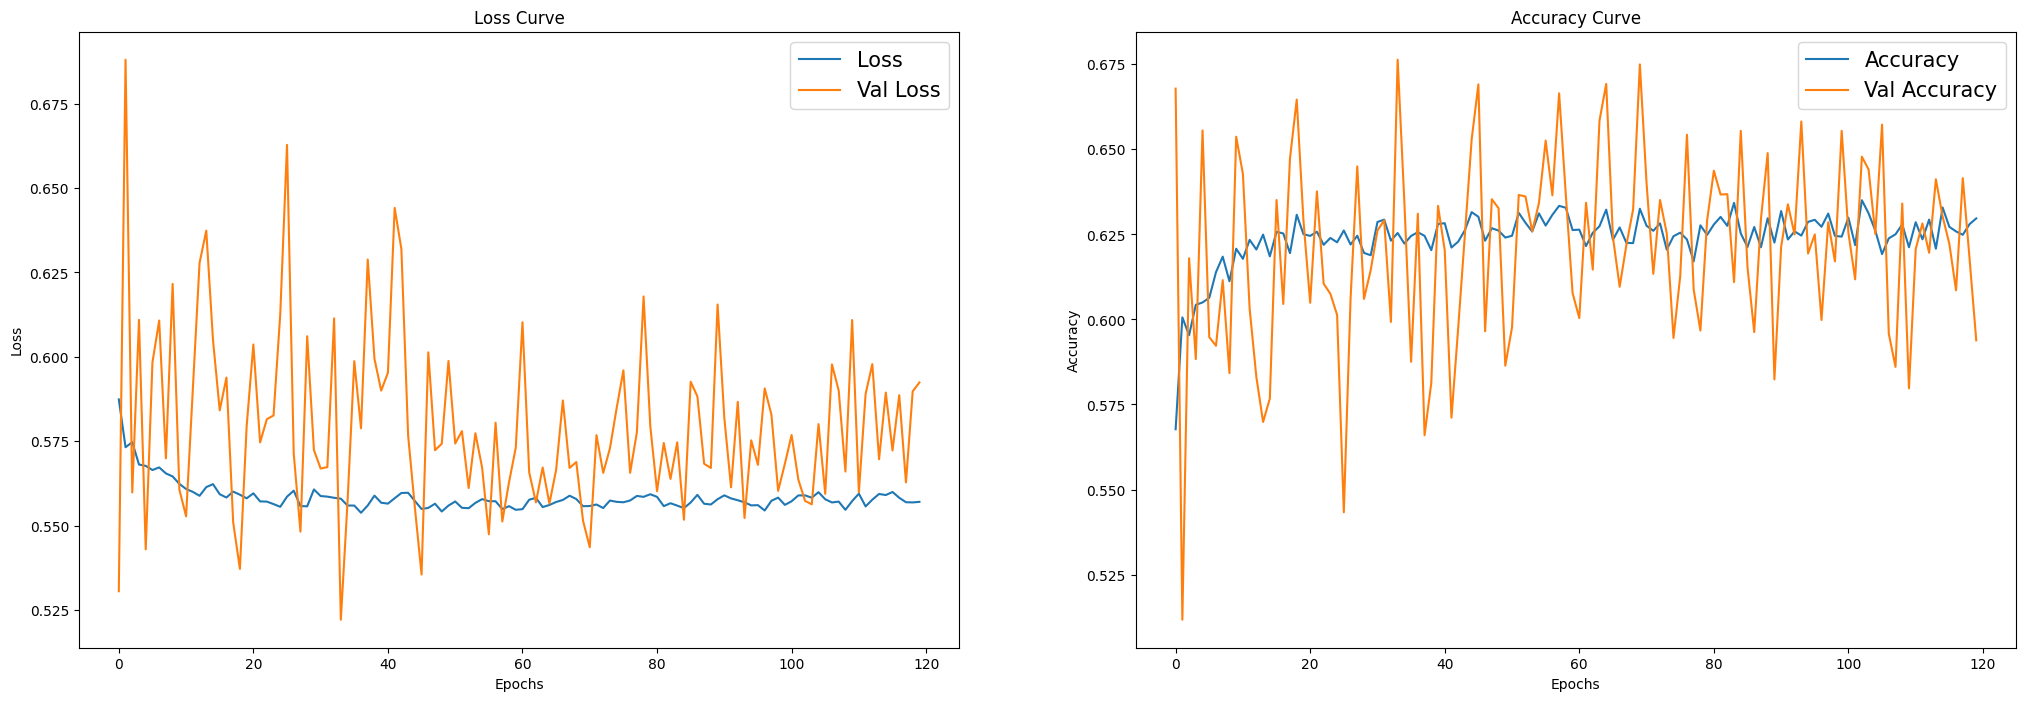

In [24]:
plot_graph(history=stepwise_logger)

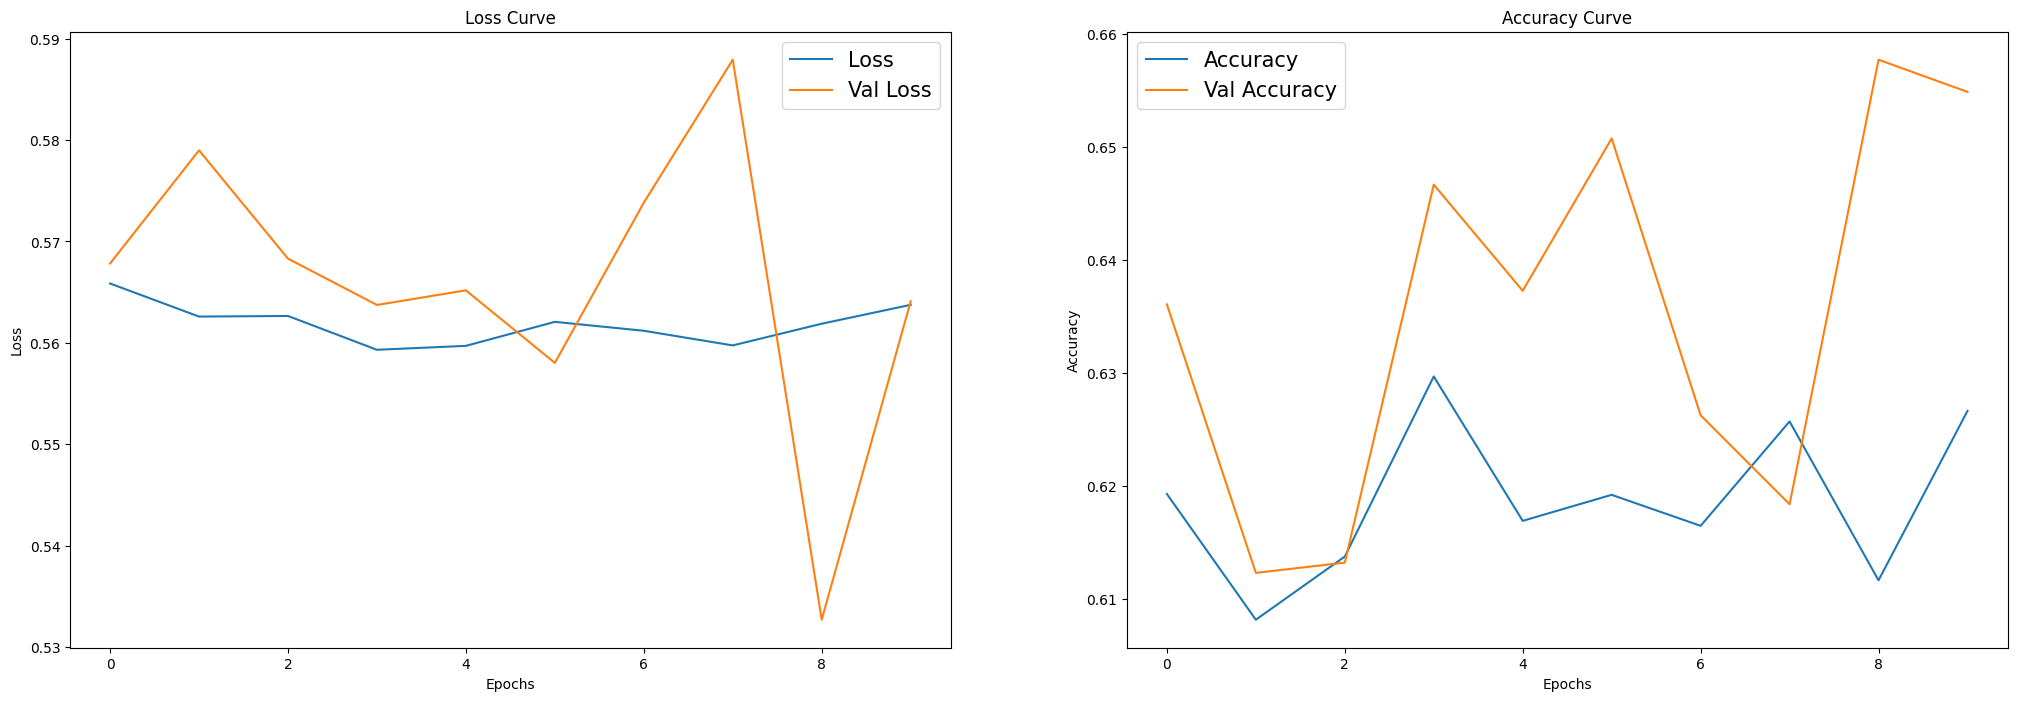

In [25]:
plot_graph(history=history)

In [26]:
model.evaluate(test_data_generator)

7544/7544 [==============================] - 66s 7ms/step - loss: 0.5647 - accuracy: 0.6542 - prc: 0.2378


[0.5647348165512085, 0.6542263627052307, 0.23775295913219452]

In [196]:
model.save(MODEL_PATH)

In [200]:
# model.save(MODEL_PATH)
with open(HISTORY_PATH, 'w') as file:
    json.dump(history.history, file)

with open(STEP_PATH, 'w') as file:
    json.dump(stepwise_logger.history, file)

# Analysis

In [95]:
predictions = model.predict(test_data_generator)

7544/7544 [==============================] - 62s 7ms/step


In [29]:
test_df = pd.read_csv(ML_DATA_TEST_PATH)

In [96]:
predictions

array([[0.66954356],
       [0.00342194],
       [0.00342194],
       ...,
       [0.01847762],
       [0.00956711],
       [0.564248  ]], dtype=float32)

In [97]:
predictions_zero_one = predictions.copy()
for prediction in predictions_zero_one:
    if prediction[0] >= 0.5:
        prediction[0] = 1
    else:
        prediction[0] = 0

predictions_zero_one = predictions_zero_one.flatten()

In [140]:
from sklearn.metrics import precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score, PrecisionRecallDisplay, RocCurveDisplay, roc_curve
import math

In [76]:
print("Accuracy Score Before Thresholding: {}".format(accuracy_score(test_df['is_blunder_cp'], predictions_zero_one)))
print("Precision Score Before Thresholding: {}".format(precision_score(test_df['is_blunder_cp'], predictions_zero_one)))
print("Recall Score Before Thresholding: {}".format(recall_score(test_df['is_blunder_cp'], predictions_zero_one)))
print("F1 Score Before Thresholding: {}".format(f1_score(test_df['is_blunder_cp'], predictions_zero_one)))

Accuracy Score Before Thresholding: 0.6542263775001916
Precision Score Before Thresholding: 0.20214329014559165
Recall Score Before Thresholding: 0.7717412623073
F1 Score Before Thresholding: 0.320371275036639


In [77]:
y_actual = pd.Series(test_df['is_blunder_cp'], name='Actual')
y_predict_tf = pd.Series(predictions_zero_one, name='Predicted')
df_confusion = pd.crosstab(y_actual, y_predict_tf, rownames=['Actual'], colnames=['Predicted'], margins=True)
print(df_confusion)

Predicted     0.0     1.0     All
Actual                           
0          276521  155306  431827
1           11638   39348   50986
All        288159  194654  482813


In [98]:
precision, recall, thresholds = precision_recall_curve(test_df['is_blunder_cp'], predictions)

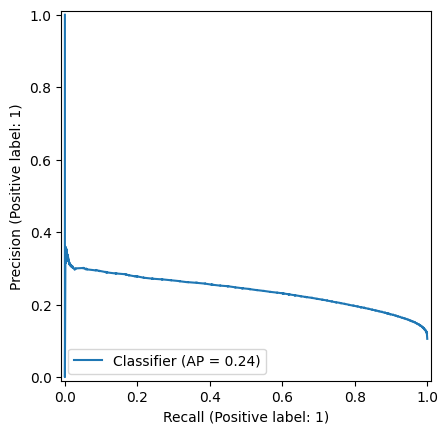

In [99]:
PrecisionRecallDisplay.from_predictions(test_df['is_blunder_cp'], predictions)

In [128]:
optimal_proba_cutoff = sorted(list(zip(2 * ((precision*recall)/(precision + recall + 0.000001)), thresholds)), key=lambda i: i[0], reverse=True)[0][1]
optimal_proba_cutoff

0.6173257

In [137]:
pr_predictions = [1 if i >= optimal_proba_cutoff else 0 for i in predictions[:, -1]]

In [138]:
print("Accuracy Score After Thresholding: {}".format(accuracy_score(test_df['is_blunder_cp'], pr_predictions)))
print("Precision Score After Thresholding: {}".format(precision_score(test_df['is_blunder_cp'], pr_predictions)))
print("Recall Score After Thresholding: {}".format(recall_score(test_df['is_blunder_cp'], pr_predictions)))
print("F1 Score After Thresholding: {}".format(f1_score(test_df['is_blunder_cp'], pr_predictions)))

Accuracy Score After Thresholding: 0.7455557327578172
Precision Score After Thresholding: 0.2307957414608198
Recall Score After Thresholding: 0.6041854626760287
F1 Score After Thresholding: 0.3340037623536938


In [139]:
y_actual = pd.Series(test_df['is_blunder_cp'], name='Actual')
y_predict_tf = pd.Series(pr_predictions, name='Predicted')
df_confusion = pd.crosstab(y_actual, y_predict_tf, rownames=['Actual'], colnames=['Predicted'], margins=True)
print(df_confusion)

Predicted       0       1     All
Actual                           
0          329159  102668  431827
1           20181   30805   50986
All        349340  133473  482813


In [135]:
fpr, tpr, thresholds_roc = roc_curve(test_df['is_blunder_cp'], predictions)

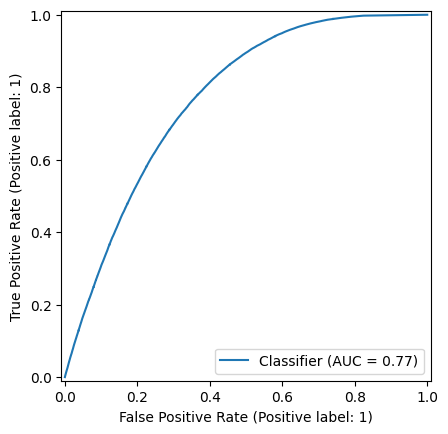

In [136]:
RocCurveDisplay.from_predictions(test_df['is_blunder_cp'], predictions)

In [190]:
optimal_roc_cutoff = sorted(list(zip(fpr**2 + (1-tpr)**2, thresholds_roc)), key=lambda i: i[0], reverse=False)[0][1]
optimal_roc_cutoff

0.5341477

In [186]:
roc_predictions = [1 if i >= optimal_roc_cutoff else 0 for i in predictions[:, -1]]

In [187]:
print("Accuracy Score After Thresholding ROC: {}".format(accuracy_score(test_df['is_blunder_cp'], roc_predictions)))
print("Precision Score After Thresholding ROC: {}".format(precision_score(test_df['is_blunder_cp'], roc_predictions)))
print("Recall Score After Thresholding ROC: {}".format(recall_score(test_df['is_blunder_cp'], roc_predictions)))
print("F1 Score After Thresholding ROC: {}".format(f1_score(test_df['is_blunder_cp'], roc_predictions)))

Accuracy Score After Thresholding ROC: 0.6833784508702127
Precision Score After Thresholding ROC: 0.2106829476075536
Recall Score After Thresholding ROC: 0.7275722747420861
F1 Score After Thresholding ROC: 0.3267491995543048


In [189]:
y_actual = pd.Series(test_df['is_blunder_cp'], name='Actual')
y_predict_tf = pd.Series(roc_predictions, name='Predicted')
df_confusion = pd.crosstab(y_actual, y_predict_tf, rownames=['Actual'], colnames=['Predicted'], margins=True)
print(df_confusion)

Predicted       0       1     All
Actual                           
0          292848  138979  431827
1           13890   37096   50986
All        306738  176075  482813
